In [1]:
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier

In [6]:
data = pd.read_csv("data/archive_10/american_bankruptcy.csv")
print("File loaded successfully!")
print(data.head())
print("Shape:", data.shape)

print(data.shape)
data.info()

File loaded successfully!
  company_name status_label  year       X1       X2      X3      X4       X5  \
0          C_1        alive  1999  511.267  833.107  18.373  89.031  336.018   
1          C_1        alive  2000  485.856  713.811  18.577  64.367  320.590   
2          C_1        alive  2001  436.656  526.477  22.496  27.207  286.588   
3          C_1        alive  2002  396.412  496.747  27.172  30.745  259.954   
4          C_1        alive  2003  432.204  523.302  26.680  47.491  247.245   

       X6       X7  ...        X9      X10      X11     X12      X13      X14  \
0  35.163  128.348  ...  1024.333  740.998  180.447  70.658  191.226  163.816   
1  18.531  115.187  ...   874.255  701.854  179.987  45.790  160.444  125.392   
2 -58.939   77.528  ...   638.721  710.199  217.699   4.711  112.244  150.464   
3 -12.410   66.322  ...   606.337  686.621  164.658   3.573  109.590  203.575   
4   3.504  104.661  ...   651.958  709.292  248.666  20.811  128.656  131.261   

      

| Variable Name   | Description                                                                                 |
|-----------------|---------------------------------------------------------------------------------------------|
| X1              | Current assets expected to be used or sold within a year                                     |
| X2              | Costs directly associated with producing goods                                              |
| X3              | Depreciation and amortization of tangible and intangible assets                             |
| X4              | Earnings before interest, taxes, depreciation, and amortization                             |
| X5              | Inventory of raw materials or products for sale                                             |
| X6              | Net profit after all expenses                                                               |
| X7              | Money owed by customers for delivered goods or services                                     |
| X8              | Market capitalization of the company                                                        |
| X9              | Net sales after accounting for returns and discounts                                        |
| X10             | Total assets owned by the company                                                          |
| X11             | Long-term debt not due within the next year                                                |
| X12             | Earnings before interest and taxes                                                         |
| X13             | Gross profit after subtracting production and selling costs                                 |
| X14             | Total current liabilities including payables and taxes                                      |
| X15             | Retained earnings after covering costs, taxes, and dividends                                |
| X16             | Total revenue from all sales before expenses                                               |
| X17             | Total liabilities owed to external parties                                                |
| X18             | Total operating expenses for running the business                                         |
| year            | Fiscal year of the data entry                                                              |
| status_label    | Company status: Active or Failed (target variable)                                        |

<Axes: title={'center': 'Class Balance'}, xlabel='Bankrupt', ylabel='Frequency'>

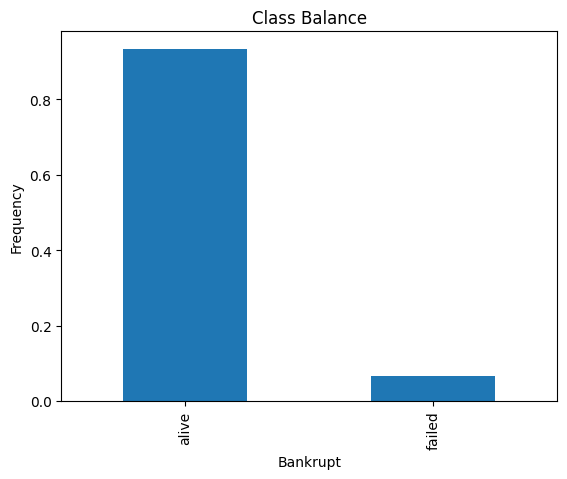

In [9]:
data['status_label'].value_counts(normalize=True).plot(
    kind = 'bar',
    xlabel = 'Bankrupt',
    ylabel = 'Frequency',
    title = 'Class Balance'
)

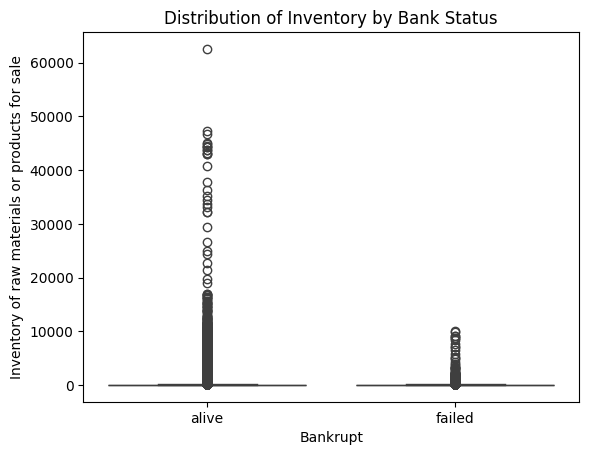

In [15]:
# we saw that there were 18 features of each company, each of which had some kind of numerical value. It might be useful to understand where tsnshe values for one of these features cluster, so let's make a boxplot to see how the values in "x5" are distributed.

sns.boxplot(x = 'status_label', y = 'X5', data = data)
plt.xlabel("Bankrupt")
plt.ylabel("Inventory of raw materials or products for sale")
plt.title("Distribution of Inventory by Bank Status");

In [14]:
data["X5"].describe().apply("{0:,.0f}".format)

count    78,682
mean        202
std       1,061
min           0
25%           0
50%           7
75%          75
max      62,567
Name: X5, dtype: str

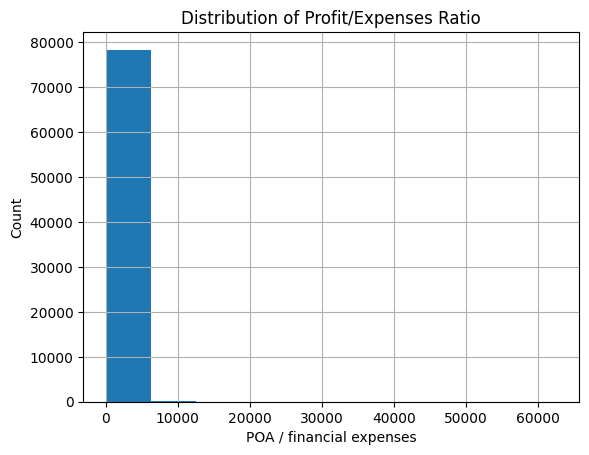

In [17]:
# Plot histogram of `feat_27`
data["X5"].hist()
plt.xlabel("POA / financial expenses")
plt.ylabel("Count"),
plt.title("Distribution of Profit/Expenses Ratio");

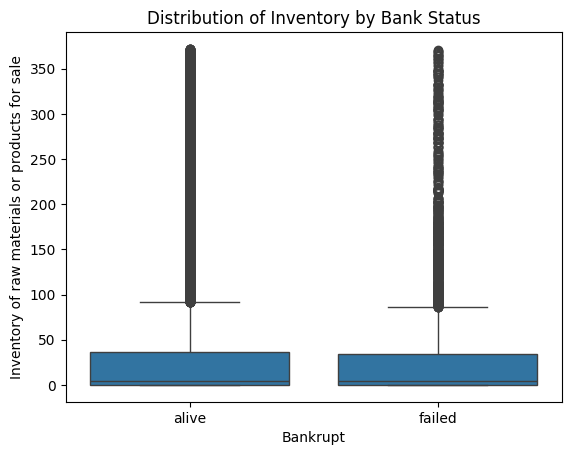

In [21]:
# Create clipped boxplot
q1, q9 = data["X5"].quantile([0.1,0.9])
mask = data["X5"].between(q1,q9)
sns.boxplot(x="status_label",y="X5", data=data[mask])
plt.xlabel("Bankrupt")
plt.ylabel("Inventory of raw materials or products for sale")
plt.title("Distribution of Inventory by Bank Status");

<Axes: >

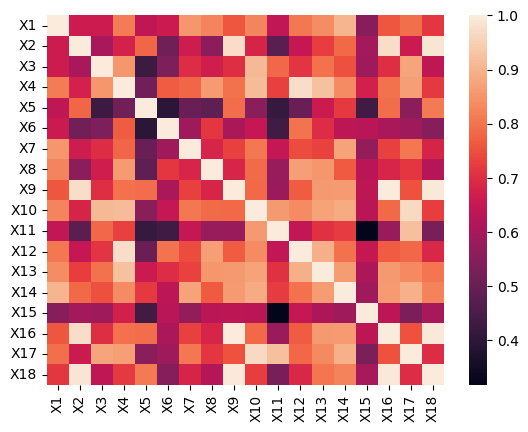

In [28]:
corr = data.drop(columns = ["status_label","company_name","year"]).corr()
sns.heatmap(corr)